Tukaj bo izvajane vse analize in filtrirane kode za vzorce, ki jih iščemo; medtem pa bo pr.py bil pomozna knjiznica za osnove funkcije kot so nalaganje tsv-jev in šiščenje podatkovnih zbirk.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from data_utils import *
import sklearn

ModuleNotFoundError: No module named 'seaborn'

Koliko obnovljive energije uporabljajo po državah skozi desetletje do zdaj (heatmap prikaz)


Loaded estat_nrg_ind_ren in 0.075s - 3759 rows


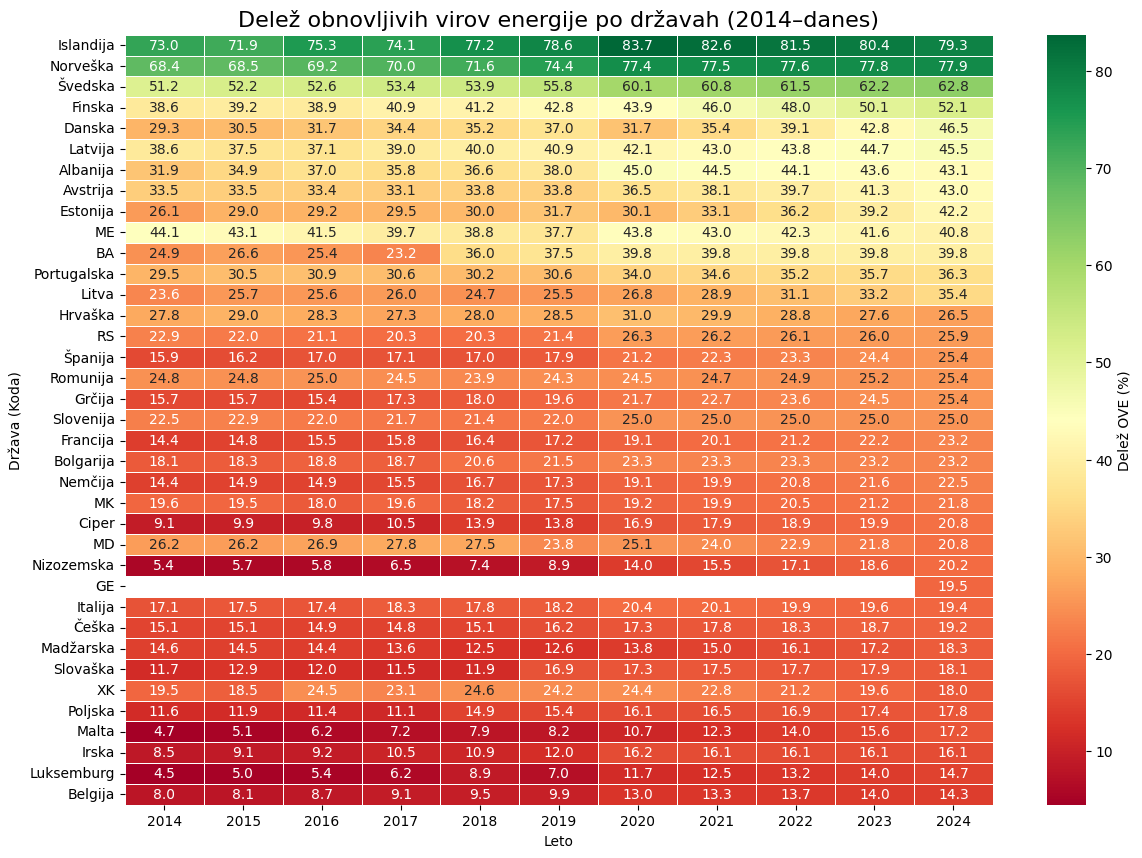

In [ ]:
df_ren = share_of_renewables()
df_ren = add_country_names(df_ren)

df_filtered = df_ren[
    (df_ren['nrg_bal'] == 'REN') & 
    (df_ren['year'] >= 2014) &
    (df_ren['geo'].str.len() == 2)
]

pivot_df = df_filtered[df_filtered['nrg_bal'] == 'REN'].pivot(index='drzava', columns='year', values='value')
pivot_df = pivot_df.interpolate(axis=1)
pivot_df = pivot_df.sort_values(by=pivot_df.columns[-1], ascending=False)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, 
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            linewidths=.5, 
            cbar_kws={'label': 'Delež OVE (%)'})

plt.title('Delež obnovljivih virov energije po državah (2014–danes)', fontsize=16)
plt.xlabel('Leto')
plt.ylabel('Država (Koda)')
plt.show()

Preskoči GE: Ni dovolj podatkov.


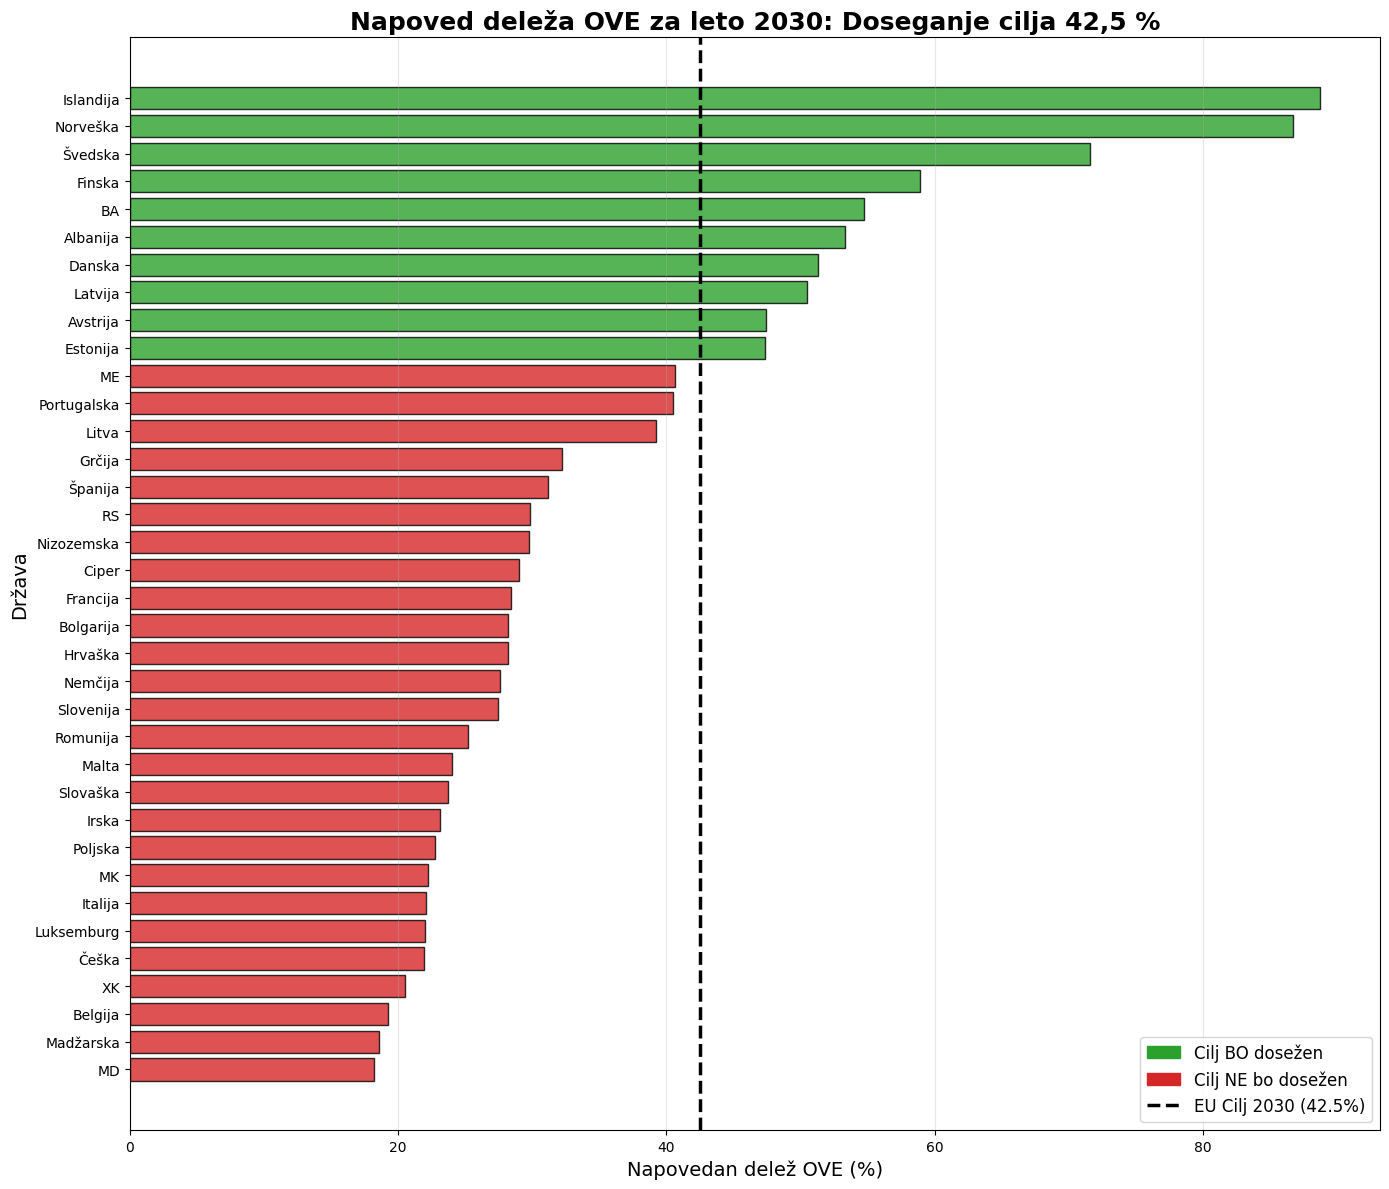

         drzava  zadnje_leto  napoved_2030  dosega_cilj
0     Islandija       79.332     88.743191         True
1      Norveška       77.932     86.730155         True
2       Švedska       62.846     71.548891         True
3        Finska       52.124     58.913336         True
10           BA       39.835     54.700400         True
6      Albanija       43.111     53.320364         True
4        Danska       46.461     51.316100         True
5       Latvija       45.535     50.456264         True
7      Avstrija       42.951     47.381464         True
8      Estonija       42.232     47.327000         True
9            ME       40.822     40.641945        False
11  Portugalska       36.319     40.501018        False
12        Litva       35.408     39.212373        False
17       Grčija       25.364     32.196582        False
15      Španija       25.417     31.159655        False
14           RS       25.862     29.844627        False
25   Nizozemska       20.180     29.774482      

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.patches as mpatches

results = []

for country in pivot_df.index:
    temp_series = pivot_df.loc[country].dropna()
    if len(temp_series) < 2:
        print(f"Preskoči {country}: Ni dovolj podatkov.")
        continue
        
    y = temp_series.values
    X = np.array(temp_series.index).reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    pred_2030 = model.predict([[2030]])[0]
    
    results.append({
        'drzava': country, 
        'zadnje_leto': y[-1], 
        'napoved_2030': pred_2030
    })


df_pred = pd.DataFrame(results)
df_pred['dosega_cilj'] = df_pred['napoved_2030'] >= 42.5
df_pred = df_pred.sort_values(by='napoved_2030', ascending=False)
df_viz = df_pred.sort_values(by='napoved_2030', ascending=True)

colors = ['#2ca02c' if x else '#d62728' for x in df_viz['dosega_cilj']]

plt.figure(figsize=(14, 12))

bars = plt.barh(df_viz['drzava'], df_viz['napoved_2030'], color=colors, edgecolor='black', alpha=0.8)

plt.axvline(x=42.5, color='black', linestyle='--', linewidth=2.5, label='EU Cilj 2030 (42.5%)')
plt.title('Napoved deleža OVE za leto 2030: Doseganje cilja 42,5 %', fontsize=18, fontweight='bold')
plt.xlabel('Napovedan delež OVE (%)', fontsize=14)
plt.ylabel('Država', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.3)

red_patch = mpatches.Patch(color='#d62728', label='Cilj NE bo dosežen')
green_patch = mpatches.Patch(color='#2ca02c', label='Cilj BO dosežen')
plt.legend(handles=[green_patch, red_patch, plt.gca().get_lines()[0]], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

print(df_pred[['drzava', 'zadnje_leto', 'napoved_2030', 'dosega_cilj']])

Za bolj podrobno analizo bomo uporabili sestavljeno letno stopnjo rasti, saj ta upošteva učinek obresti.

C:\Users\skvar\AppData\Local\Temp\ipykernel_22260\3001088953.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cagr_s, y=cagr_s.index, palette='viridis')


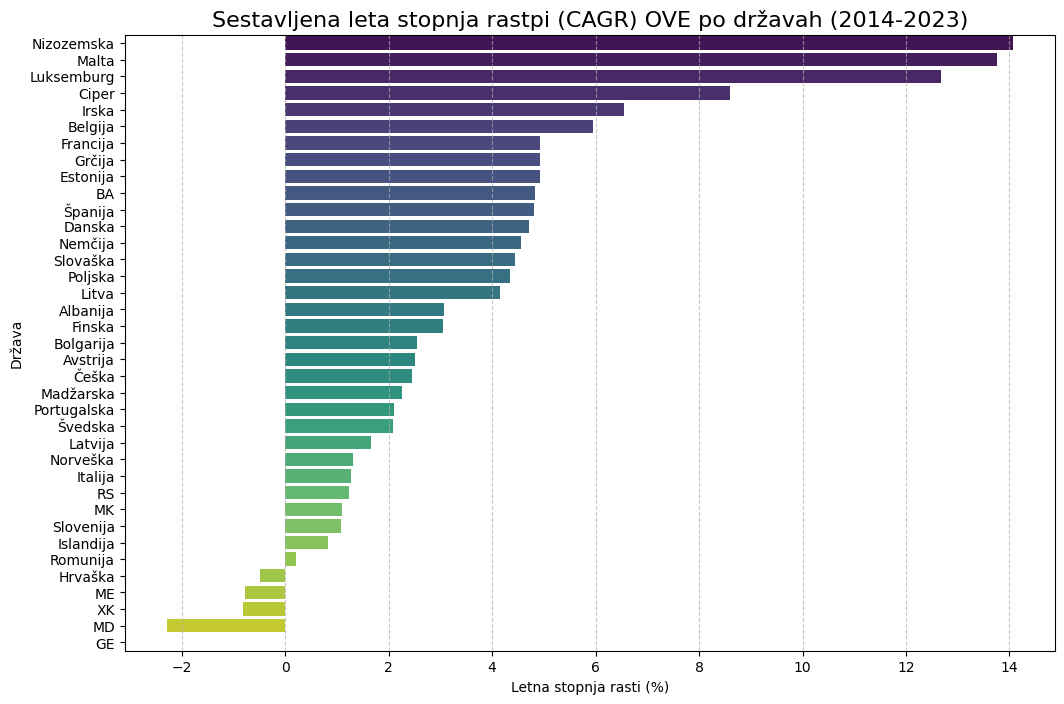

drzava
Nizozemska     14.059712
Malta          13.753199
Luksemburg     12.671785
Ciper           8.588663
Irska           6.552049
Belgija         5.956596
Francija        4.925624
Grčija          4.924972
Estonija        4.918053
BA              4.822295
Španija         4.816611
Danska          4.714609
Nemčija         4.565671
Slovaška        4.443603
Poljska         4.352829
Litva           4.143858
Albanija        3.071758
Finska          3.040494
Bolgarija       2.546252
Avstrija        2.500994
Češka           2.454761
Madžarska       2.251760
Portugalska     2.098512
Švedska         2.080397
Latvija         1.658381
Norveška        1.312297
Italija         1.272775
RS              1.239733
MK              1.095749
Slovenija       1.078013
Islandija       0.829353
Romunija        0.212487
Hrvaška        -0.492492
ME             -0.768961
XK             -0.808574
MD             -2.284638
GE                   NaN
dtype: float64


In [ ]:
def izracun_cagr(df_pivot):
    # cagr Izračunamo na podlagi prvega in zadnjega leta v pivot tabeli
    df_prvo = df_pivot.columns[0]
    df_zadnje = df_pivot.columns[-1]
    n_let = df_zadnje - df_prvo

    cagr = ((df_pivot[df_zadnje] /df_pivot[df_prvo])** (1/n_let) - 1)
    return cagr *100

#CAGR za vse države
cagr_s = izracun_cagr(pivot_df).sort_values(ascending=False)

#Vizualizacija 
plt.figure(figsize=(12, 8))
sns.barplot(x=cagr_s, y=cagr_s.index, palette='viridis')
plt.title("Sestavljena leta stopnja rastpi (CAGR) OVE po državah (2014-2023)", fontsize=16)
plt.xlabel("Letna stopnja rasti (%)")
plt.ylabel("Država")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(cagr_s)

Ugotoviti želimo ali imajo bogatejše države kakšno prednost pred revnejšimi in si lahko tako privoščijo hitrejši prehod.

Loaded sdg_08_10_tabular in 0.033s - 2106 rows


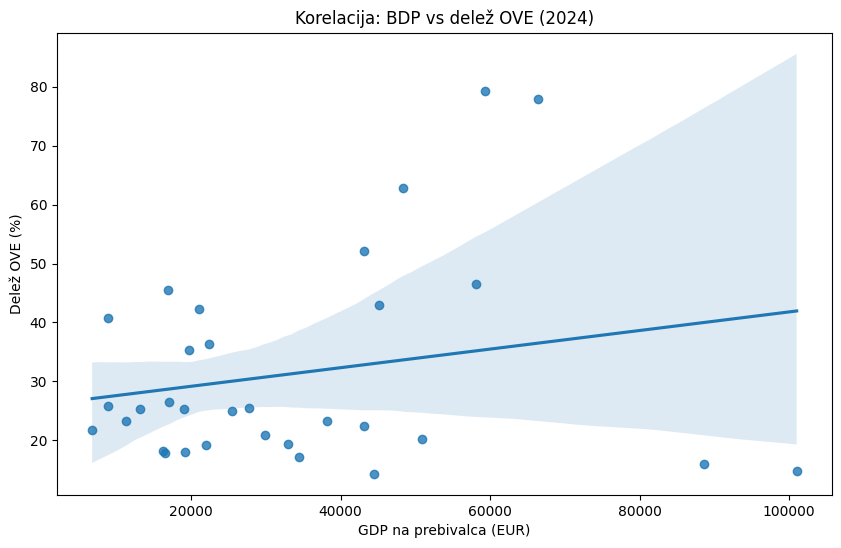

Pearsonov korelacijski koeficient: 0.21


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Uvoz in dodajanje imen
df_gdp_raw = load_tsv("sdg_08_10_tabular", "data")
df_gdp = add_country_names(df_gdp_raw)

zadnje_leto = pivot_df.columns[-1]


df_gdp_fix = df_gdp[
    (df_gdp["unit"].str.contains("CLV", na=False)) & 
    (df_gdp["unit"].str.contains("EUR_HAB", na=False)) &
    (df_gdp["year"] == zadnje_leto) & 
    (df_gdp["value"] > 1000)
].copy()

#Združevanje
analiza_df = pd.DataFrame({
    "OVE_delez": pivot_df[zadnje_leto],
    "CAGR": cagr_s
}).merge(df_gdp_fix[['drzava', 'value']], left_index=True, right_on='drzava')

analiza_df.rename(columns={'value': 'GDP_per_capita'}, inplace=True)

# ćiščenje praznih vrednosti
analiza_clean = analiza_df.copy()
analiza_clean['GDP_per_capita'] = pd.to_numeric(analiza_clean['GDP_per_capita'], errors='coerce')
analiza_clean['OVE_delez'] = pd.to_numeric(analiza_clean['OVE_delez'], errors='coerce')

# odstranimo vrednosti kjer ni obeh podatkov
analiza_clean = analiza_clean.dropna(subset=['GDP_per_capita', 'OVE_delez'])

#Regresija
if not analiza_clean.empty:
    X = analiza_clean[['GDP_per_capita']].values
    y = analiza_clean['OVE_delez'].values
    
    model = LinearRegression().fit(X, y)
    analiza_clean["ostanek"] = y - model.predict(X)
    
    
    plt.figure(figsize=(10, 6))
    sns.regplot(data=analiza_clean, x="GDP_per_capita", y="OVE_delez")
    plt.title(f"Korelacija: BDP vs delež OVE ({zadnje_leto})")
    plt.xlabel("GDP na prebivalca (EUR)")
    plt.ylabel("Delež OVE (%)")
    plt.show()
    
    korelacija = analiza_clean['GDP_per_capita'].corr(analiza_clean['OVE_delez'])
    print(f"Pearsonov korelacijski koeficient: {korelacija:.2f}")



najti moramo države ki najbolj izstopajo iz povprečja, torej imajo ali zelo visok OVE in nizek BDP ali pa obratno


In [ ]:
from sklearn.linear_model import LinearRegression

analiza_clean = analiza_df.dropna(subset=['GDP_per_capita', 'OVE_delez']).copy()

X = analiza_clean[['GDP_per_capita']].values
y = analiza_clean['OVE_delez'].values

model = LinearRegression().fit(X,y)
napoved = model.predict(X)
analiza_clean['ostanek'] = y- napoved

#top 3 odkloni gor in dol
pozitivni_odkl = analiza_clean.sort_values(by='ostanek', ascending=False).head(3)
negativni_odkl = analiza_clean.sort_values(by='ostanek', ascending=True).head(3)

print("Države ki presegajo pričakkovana glede na BDP:")
print(pozitivni_odkl[["drzava", "OVE_delez", "GDP_per_capita"]])

print("\nDržave ki zaostajajo glede na BDP:")
print(negativni_odkl[["drzava", "OVE_delez", "GDP_per_capita"]])

Države ki presegajo pričakkovana glede na BDP:
         drzava  OVE_delez  GDP_per_capita
1966  Islandija     79.332         59270.0
1975   Norveška     77.932         66460.0
1980    Švedska     62.846         48310.0

Države ki zaostajajo glede na BDP:
          drzava  OVE_delez  GDP_per_capita
1969  Luksemburg     14.742        101000.0
1965       Irska     16.064         88600.0
1947     Belgija     14.336         44440.0
